# Exercício: Classificação com SVM RBF em Dados Estilo Checkerboard

Você irá:

1. Gerar um conjunto de dados com padrão de tabuleiro (checkerboard).
2. Treinar um modelo SVM com kernel RBF.
3. Visualizar os pontos e os vetores de suporte.
4. Explorar diferentes valores de `C`, `gamma` e da quantidade de tiles.

---

## Passo 1: Gerar os dados

Use a função abaixo para gerar pontos em `[0,1]^2` com classes alternadas em padrão de tabuleiro:

    import numpy as np

    def generate_checkerboard(n_samples=1000, n_tiles=3, seed=42):
        np.random.seed(seed)
        X = np.random.uniform(0, 1, size=(n_samples, 2))
        y = ((np.floor(X[:, 0] * n_tiles) + np.floor(X[:, 1] * n_tiles)) % 2).astype(int)
        return X, y

Exemplo:

    X, y = generate_checkerboard()

Experimente mudar o valor de `n_tiles` (por exemplo: `n_tiles = 2, 4, 6`) e observe como o padrão se torna mais complexo.

---

## Passo 2: Treinar o modelo

Treine um classificador SVM com kernel `'rbf'`:

    from sklearn.svm import SVC

    C = 10
    gamma = 1
    model = SVC(kernel='rbf', C=C, gamma=gamma)
    model.fit(X, y)

---

## Passo 3: Visualizar os resultados

Plote os dados com `matplotlib.pyplot.scatter`, colorindo os pontos pela classe e destacando os vetores de suporte em preto.

---

## Passo 4: Extrair os vetores de suporte

Use a função abaixo para obter os vetores de suporte do modelo treinado:

    model.support_vectors_

---

## Passo 5: Explorar os hiperparâmetros

Repita os passos anteriores para diferentes combinações de:

- `C = 1, 10, 100`
- `gamma = 0.1, 1, 10`
- `n_tiles = 2, 3, 4`

Documente suas conclusões.

<Axes: xlabel='x1', ylabel='x2'>

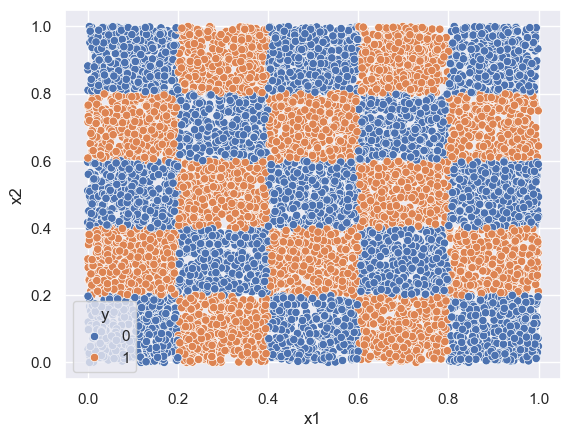

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme()

def generate_checkerboard(n_samples=1000, n_tiles=3, seed=42):
        np.random.seed(seed)
        X = np.random.uniform(0, 1, size=(n_samples, 2))
        y = ((np.floor(X[:, 0] * n_tiles) + np.floor(X[:, 1] * n_tiles)) % 2).astype(int)
        return X, y

X, y = generate_checkerboard(n_samples=10000, n_tiles=5)
data = pd.DataFrame(X, columns=['x1', 'x2'])
data['y'] = y

sns.scatterplot(data=data,x='x1', y='x2', hue='y')

In [33]:
from sklearn.svm import SVC

C = 100
gamma = 10
model = SVC(kernel='rbf', C=C, gamma=gamma)
model.fit(X, y)

SVC(C=100, gamma=10)

<Axes: xlabel='x1', ylabel='x2'>

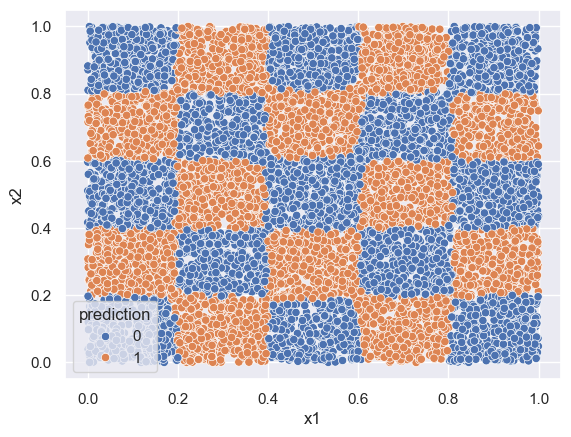

In [34]:
data['prediction'] = model.predict(X)
sns.scatterplot(data=data,x='x1', y='x2', hue='prediction')

Text(0.5, 1.0, 'SVM, C=100, gamma=10')

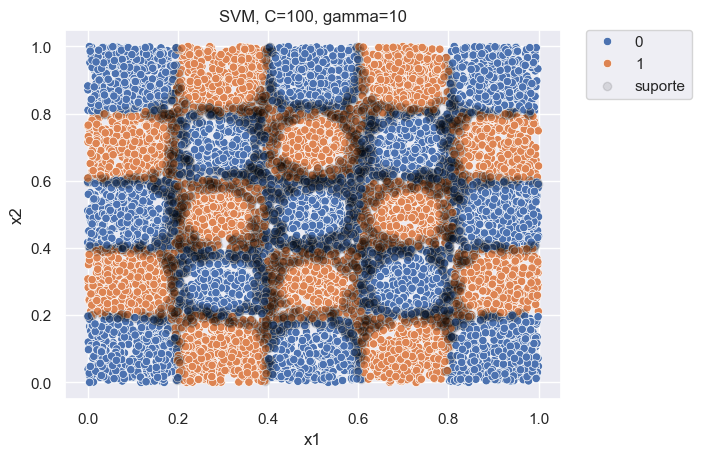

In [64]:
suport = pd.DataFrame(model.support_vectors_, columns=['x1', 'x2'])

fig, ax = plt.subplots()

sns.scatterplot(
    data=data,
    x='x1',
    y='x2',
    hue='prediction',
    ax=ax
)

ax.scatter(
    x=suport['x1'],
    y=suport['x2'],
    color='black',
    alpha=0.1,
    label='suporte'
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_title("SVM, C=100, gamma=10")

# Exercício: Curva de Aprendizado com AdaBoost

Você irá:

- Carregar o arquivo `boost.csv`.
- Separar os dados em treino e calibração.
- Treinar um modelo `AdaBoostClassifier`.
- Usar `staged_predict` para calcular o erro de classificação em cada etapa.
- Plotar as curvas de erro no treino e calibração ao longo das iterações.

---

## Importações

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import AdaBoostClassifier
    from sklearn.metrics import zero_one_loss

---

## Observação sobre `staged_predict`

O método `staged_predict` do AdaBoost permite acessar as **previsões parciais** do modelo a cada iteração (número crescente de estimadores).

Você pode usá-lo assim:

    for y_pred in model.staged_predict(X):
        erro = zero_one_loss(y_true, y_pred)

Para comparar treino e calibração simultaneamente:

    for y_pred_train, y_pred_calib in zip(
        model.staged_predict(X_train),
        model.staged_predict(X_calib)
    ):
        # calcule e armazene os erros para treino e calibração


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import zero_one_loss

/opt/homebrew/Caskroom/miniconda/base/envs/random/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/random/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


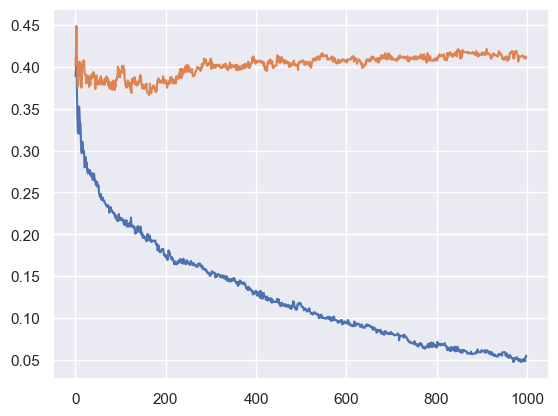

In [88]:
df = pd.read_csv("boost.csv", index_col="Unnamed: 0")

X = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']]
y = df['y']

X_train, X_calib, y_train, y_calib = train_test_split(X, y, test_size=.40, random_state=42)

model = AdaBoostClassifier(n_estimators=1000)
model.fit(X_train, y_train)


erro_train = []
erro_calib = []

for y_pred_train, y_pred_calib in zip(
        model.staged_predict(X_train),
        model.staged_predict(X_calib)
    ):

    erro_train.append(zero_one_loss(y_train, y_pred_train))
    erro_calib.append(zero_one_loss(y_calib, y_pred_calib))

plt.plot(erro_train)
plt.plot(erro_calib)

# Exercício: Intervalo de Predição com Gradient Boosting

$$
l(g(x), z) = (z-g(x))(I(g(x)\leq z)-\alpha))
$$

Neste exercício, você irá:

- Gerar um dataset com variância heterocedástica.
- Visualizar a função geradora.
- Utilizar regressão quantílica com Gradient Boosting para estimar intervalos de predição de 90%.

---

## 1. Gerar o dataset

Utilize a função abaixo para gerar os dados. Ela simula uma relação não linear com variância que depende da posição:

    def make_variable_data(n, std_dev=1/5):
        x = np.random.uniform(low=-1, high=1, size=n)
        y = (x**3) + 2 * np.exp(-6 * (x - 0.3)**2)
        y = y + np.random.normal(scale=std_dev * np.abs(x), size=n)
        df = pd.DataFrame({'x': x, 'y': y})
        return df

Gere os dados com `n = 2000` e plote os pontos junto com a curva determinística (isto é, sem o ruído) para visualizar a variabilidade dos dados.

---

## 2. Separar os dados

Use `train_test_split` para dividir os dados em treino e teste.

---

## 3. Treinar modelos quantílicos

Treine três modelos `GradientBoostingRegressor` com `loss='quantile'` usando:

- `alpha = 0.05` para o limite inferior
- `alpha = 0.5` para a mediana
- `alpha = 0.95` para o limite superior

---

## 4. Visualizar os resultados

Plote os dados de treino como pontos, a curva da mediana como linha, e o intervalo de predição como duas curvas (superior e inferior) com cores diferentes.

---

Esse exercício mostra como estimar intervalos de predição com Gradient Boosting e como eles se adaptam à variância dos dados.


<Axes: xlabel='x', ylabel='y'>

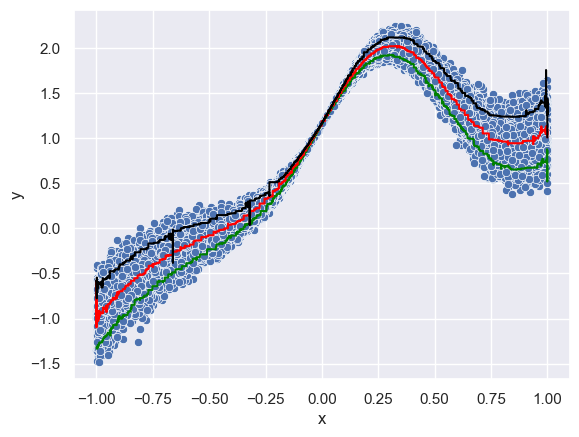

In [109]:
from sklearn.ensemble import GradientBoostingRegressor

def make_variable_data(n, std_dev=1/5):
    x = np.random.uniform(low=-1, high=1, size=n)
    y = (x**3) + 2 * np.exp(-6 * (x - 0.3)**2)
    y = y + np.random.normal(scale=std_dev * np.abs(x), size=n)
    df = pd.DataFrame({'x': x, 'y': y})
    return df

df = make_variable_data(100000, std_dev=1/5)

X = df[['x']]
y = df['y']

X_train, X_calib, y_train, y_calib = train_test_split(X, y, test_size=.40, random_state=42)
df_test = X_calib.copy()
df_test['y'] = y_calib

model = GradientBoostingRegressor(n_estimators=500,loss='quantile', alpha=0.05)
model.fit(X_train, y_train)
df_test['pred_05'] = model.predict(X_calib)

model = GradientBoostingRegressor(n_estimators=500,loss='quantile', alpha=0.5)
model.fit(X_train, y_train)
df_test['pred_50'] = model.predict(X_calib)

model = GradientBoostingRegressor(n_estimators=500,loss='quantile', alpha=0.95)
model.fit(X_train, y_train)
df_test['pred_95'] = model.predict(X_calib)

sns.scatterplot(data=df_test, x='x', y='y')

sns.lineplot(data=df_test, x='x', y='pred_05', color='green')
sns.lineplot(data=df_test, x='x', y='pred_50', color='red')
sns.lineplot(data=df_test, x='x', y='pred_95', color='black')